# COMP3010 2026 Sem1 Machine Learning Final Assignment
## Author: Ethan Ty Riekert --- 22208187@student.curtin.edu.au

In this assignment, the main task is to perform a predictive analysis on the peak pressure generated by BLEVEs. Consider a scenario where a BLEVE occurs inside a rectangular tank located within a three-dimensional environment, positioned near a rigid obstacle (e.g a wall). The blast wave will interact with the obstable, producing reflections and complex pressure patterns that increase the complexity of the pressure distribution. The objective is to accurately predict the peak pressure in the vicinity of the obstacle.

The dataset includes:
- **27 sensors** (front, back, and side walls)  
- **Multiple physical and geometric input variables**, including:  
  - Tank dimensions  
  - Vapour/liquid temperatures  
  - Liquid ratio  
  - BLEVE height  
  - Obstacle geometry  
  - Sensor coordinates  
- **Target variable:** peak pressure (bar)

The provided files are:
- `train.csv` — includes all features + target pressure  
- `test.csv` — includes all features, target withheld  
- `sample_prediction.csv` — required output format  

The task is to:
1. Preprocess the data  
2. Develop and compare multiple ML models  
3. Generate final predictions for Kaggle submission  
4. Document the workflow in a report

#### Importing Base Modules For Program

In [660]:
import numpy as np # efficient vectors and tensors
import pandas as pd # data handling
import matplotlib.pyplot as plt # plots

# Neural Networks
import torch
import torch.nn as F

# Data Preprocessing
from sklearn.feature_selection import mutual_info_regression # Section 1.9
from sklearn.model_selection import train_test_split # Section 1.11
from sklearn.preprocessing import StandardScaler, QuantileTransformer # Section 1.10, 1.12
import joblib # Section 1.12

# For function definitions
from typing import Tuple

## 1.0 Data Preprocessing
We are asked to:
- Identify and Handle Missing Values **DONE 1.6**
- Outlier Detection and Treatment **DONE 1.4**
- Duplicate Removal **DONE 1.3**
- Correcting Inaccurate Entries **DONE 1.7**
- Feature selection and consideration of building a 'sparse' model **DONE 1.2 and 1.9**
- Feature Engineering **DONE 1.8**
- Data Type Conversion **DONE 1.5**
- Feature Scaling **DONE 1.11**
- Data Augmentation **DONE 1.12**
We also do:
- Train / Validation Splitting **1.10**
- Target Quantile Transformation **1.13**

First we start with understanding the data we are dealing with, so that we can preprocess it

In [661]:
# Defining the route to data
route = "../Data/"

# Assigning the data to pandas dataframes
df_test = pd.read_csv(f"{route}test.csv")
df_train = pd.read_csv(f"{route}train.csv")
df_predictions = pd.read_csv(f"{route}sample_prediction.csv")

pd.set_option("display.precision", 2) # Don't need good precision for viewing data

### 1.1 Exploring the type of information held by each set

In [662]:
##       Exploring the type of information held by each set         ##
# Calculating Missing Values
missingVal_test = df_test.isnull().sum().sum()
missingVal_train = df_train.isnull().sum().sum()
missingVal_pred = df_predictions.isnull().sum().sum()

# Calculating Percentiles
# Probably could all be done in some list or loop
num_train = df_train.select_dtypes(include='number')

Q1 = num_train.quantile(0.25)
Q3 = num_train.quantile(0.75)
IQR = Q3 - Q1

train_lower_quartile = Q1 - 1.5 * IQR
train_upper_quartile = Q3 + 1.5 * IQR

outliers_train = ((num_train < train_lower_quartile)).sum() + (num_train > train_upper_quartile).sum()


# Checking for duplicate values
test_dup = df_test.duplicated().sum()
train_dup = df_train.duplicated().sum()
pred_dup = df_predictions.duplicated().sum()

# Checking correlation matrix for feature relations
train_corr = df_train.corr(numeric_only=True).abs()

# Upper triangle mask (exclude diagonal)
train_upper = train_corr.where(np.triu(np.ones(train_corr.shape), k=1).astype(bool))

# Sort all pairs by correlation strength
train_sorted_pairs = train_upper.stack().sort_values(ascending=False)


test_corr = df_test.corr(numeric_only=True).abs()

# Upper triangle mask (exclude diagonal)
test_upper = test_corr.where(np.triu(np.ones(test_corr.shape), k=1).astype(bool))

# Sort all pairs by correlation strength
test_sorted_pairs = test_upper.stack().sort_values(ascending=False)




#### 1.1.1 Checking the first (test) dataset

Missing values: 0
Duplicate values: 0
Shape: (3203, 24)
Dtypes: 
float64    15
int64       8
str         1
Name: count, dtype: int64



Correlated Features

Liquid Critical Pressure (bar)  Liquid Critical Temperature (K)    1.00
                                Liquid Boiling Temperature (K)     1.00
Liquid Boiling Temperature (K)  Liquid Critical Temperature (K)    1.00
Obstacle Distance to BLEVE (m)  Sensor Position x                  0.98
Sensor ID                       Sensor Position Side               0.93
dtype: float64


,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Thickness (m),Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z
count,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,...,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00
mean,1601.00,21.31,0.49,1.77,5.13,1.57,1.04,0.83,402.83,342.69,...,1.70,13.79,40.11,-20.70,125.43,13.97,2.33,13.02,2.90,3.38
std,924.77,10.12,0.22,0.74,2.55,0.70,0.57,0.53,73.49,37.19,...,0.79,9.02,2.30,20.49,27.63,7.79,1.33,4.34,4.50,4.47
min,0.00,5.10,0.10,0.40,0.60,0.40,0.00,0.20,292.60,283.10,...,0.40,0.00,37.90,-42.00,96.70,1.00,1.00,5.15,-6.85,-2.90
25%,800.50,13.20,0.28,1.00,3.20,1.00,0.60,0.40,341.60,313.10,...,1.00,6.00,37.90,-42.00,96.70,7.00,1.00,9.35,0.15,-0.60
50%,1601.00,20.60,0.50,1.80,4.60,1.40,1.00,0.60,391.90,340.50,...,1.80,13.00,37.90,-1.00,152.00,14.00,2.00,12.60,2.85,2.50
75%,2401.50,30.70,0.68,2.40,7.40,2.20,1.60,1.20,438.80,368.80,...,2.40,22.00,42.50,-1.00,152.00,21.00,3.00,16.38,6.10,6.10
max,3202.00,42.00,0.88,3.00,9.80,3.00,2.00,2.40,571.80,424.40,...,3.00,30.00,42.50,-1.00,152.00,27.00,5.00,22.95,17.25,16.50


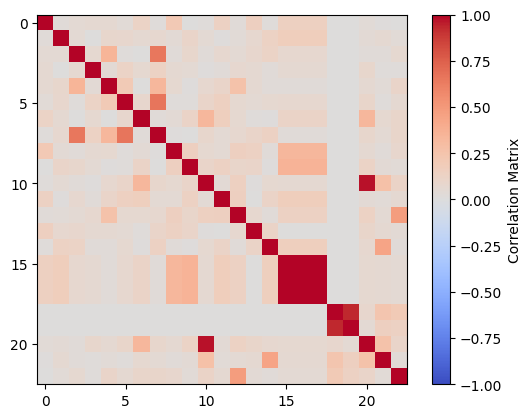

In [663]:
# NTS: We have no need to see the .head() as we have the .csv downloaded permanently. Can check that
print(f"Missing values: {missingVal_test}")
print(f"Duplicate values: {test_dup}")
print(f"Shape: {df_test.shape}")
print(f"Dtypes: \n{df_test.dtypes.value_counts()}\n\n")
print("\nCorrelated Features\n")
print(test_sorted_pairs[test_sorted_pairs > 0.8])
plt.figure()
plt.imshow(test_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Matrix')

df_test.describe()

##### Analysis
We have no duplicate or missing values that we have to take care of. However, there are some values that exist outside the $98\%$ percentile that we have to see how the model will react to, and there is one categorical column we have to encode.  

However, we note that the testing set has 15 floats and 8 ints while the training set has 24 floats, meaning that the integers in the testing set have to be converted into floats.

Moreover, the testing set shows some correlated features that we should see in the training set

#### 1.1.2 Checking the second (train) dataset (most important)

Missing values: 302
Duplicate values: 50
Shape: (10050, 25)
Dtypes: 
float64    24
str         1
Name: count, dtype: int64


------
Outiers: 
ID                                   0
Tank Failure Pressure (bar)         50
Liquid Ratio (%)                     0
Tank Width (m)                       0
Tank Length (m)                      0
Tank Height (m)                      0
BLEVE Height (m)                     0
Vapour Height (m)                   71
Vapour Temperature (K)               0
Liquid Temperature (K)               0
Obstacle Distance to BLEVE (m)       0
Obstacle Width (m)                   0
Obstacle Height (m)                  0
Obstacle Thickness (m)               0
Obstacle Angle                       0
Liquid Critical Pressure (bar)       0
Liquid Boiling Temperature (K)       0
Liquid Critical Temperature (K)      0
Sensor ID                            0
Sensor Position Side                 0
Sensor Position x                    0
Sensor Position y                   10


,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Thickness (m),Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z
count,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,...,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00,3203.00
mean,1601.00,21.31,0.49,1.77,5.13,1.57,1.04,0.83,402.83,342.69,...,1.70,13.79,40.11,-20.70,125.43,13.97,2.33,13.02,2.90,3.38
std,924.77,10.12,0.22,0.74,2.55,0.70,0.57,0.53,73.49,37.19,...,0.79,9.02,2.30,20.49,27.63,7.79,1.33,4.34,4.50,4.47
min,0.00,5.10,0.10,0.40,0.60,0.40,0.00,0.20,292.60,283.10,...,0.40,0.00,37.90,-42.00,96.70,1.00,1.00,5.15,-6.85,-2.90
25%,800.50,13.20,0.28,1.00,3.20,1.00,0.60,0.40,341.60,313.10,...,1.00,6.00,37.90,-42.00,96.70,7.00,1.00,9.35,0.15,-0.60
50%,1601.00,20.60,0.50,1.80,4.60,1.40,1.00,0.60,391.90,340.50,...,1.80,13.00,37.90,-1.00,152.00,14.00,2.00,12.60,2.85,2.50
75%,2401.50,30.70,0.68,2.40,7.40,2.20,1.60,1.20,438.80,368.80,...,2.40,22.00,42.50,-1.00,152.00,21.00,3.00,16.38,6.10,6.10
max,3202.00,42.00,0.88,3.00,9.80,3.00,2.00,2.40,571.80,424.40,...,3.00,30.00,42.50,-1.00,152.00,27.00,5.00,22.95,17.25,16.50


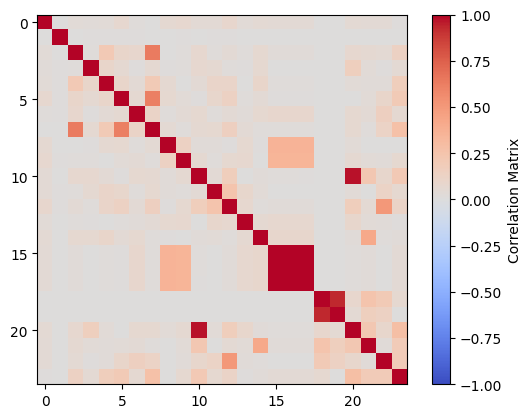

In [664]:

# NTS: We have no need to see the .head() as we have the .csv downloaded permanently. Can check that
print(f"Missing values: {missingVal_train}")
print(f"Duplicate values: {train_dup}")
print(f"Shape: {df_train.shape}")
print(f"Dtypes: \n{df_train.dtypes.value_counts()}\n\n")
print(f"------\nOutiers: \n{outliers_train}\n\n-----")

# Correaltion matrix plot
plt.figure()
plt.imshow(train_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Matrix')
# Show only correlations above a threshold
print("\nCorrelated Features\n")
print(train_sorted_pairs[train_sorted_pairs > 0.8])

df_test.describe()

#### Analysis
Both the training and testing set hold the same amount of features (training has the predictions as well so 1 extra column). The training set has **302 missing values** that we need to handle, as well as **50 duplicate values**. There is one str feature such that we have to **encode** it, and there exist over a **hundred outliers** (above 98% percentile) for each feature that we have to handle. 

We then look at the correlation matrix to find **redundent (or related) features**. The matrix and output tell us that the liquid critical pressure (bar) and liquid critical temperature (K), as well has liquid boiling temperature (K) have a perfect 1.0 correlation such that they represent the exact same thing. We can get rid of 2 of the three columns 17,18,19. 

Moreover, the obstacle distance to BLEVE (m) and Sensor Position x have a correlation of 0.97. Potentially the x distance from the BLEVE is entirely determined by the x-coordinate (which makes sense), HOWEVER, the provided research paper [2] mentioned that this is one of the most important features, and so we shall keep it.

The Sensor ID and Sensor Position Side have a correlation of 0.93 however, sensor id is metadata that we do not need aswell as the normal ID for each input so we can get rid of both of them

#### 1.1.3 Checking the third (predictions) dataset

In [665]:
print(f"Missing values {df_predictions.isnull().sum().sum()}")
print(df_predictions.shape)
print(df_predictions.info())
df_predictions.describe()

Missing values 0
(3203, 2)
<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     3203 non-null   int64  
 1   Target Pressure (bar)  3203 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.2 KB
None


,ID,Target Pressure (bar)
count,3203.00,3.20e+03
mean,1601.00,4.96e-01
std,924.77,2.88e-01
min,0.00,2.62e-04
25%,800.50,2.43e-01
50%,1601.00,5.03e-01
75%,2401.50,7.44e-01
max,3202.00,9.97e-01


#### 1.1.4 Sanity checks

In [666]:
assert len(df_predictions) == len(df_test)

### 1.2 Redundant Data
We get rid of the redundent features as it will speed up (optimize) most other manipulating we do with the data (less features for the machine to work with). As stated before, we will get rid of the sensor ID and the normal ID as they are just metadata, distance from BLEVE (as x coordinate already relates to this) we will keep despite it being related to x coordinate as it shows significance in the research paper [2], and the critical pressure and boiling temperature will be removed as they are 100% related to the critical temperature (K).

Importantly, as we are provided two seperate files for the testing set and predictions, we have to ensure that they share the same ID / index before removing it

In [667]:
# Before removing ID just ensure it matches up with the actual index
# Check that ID matches the index exactly
id_matches_index = (df_test["ID"].values == df_test.index.values).all()
print("ID matches index:", id_matches_index)

# 3. Check that IDs are unique and sequential
ids_unique = df_test["ID"].is_unique
ids_sequential = (df_test["ID"].values == np.arange(len(df_test))).all()

print("IDs unique:", ids_unique)
print("IDs sequential 0..N-1:", ids_sequential)

ID matches index: True
IDs unique: True
IDs sequential 0..N-1: True


In [668]:
df_train = df_train.drop(columns=['ID', 'Sensor ID', 'Liquid Critical Pressure (bar)', 'Liquid Boiling Temperature (K)'])

df_test = df_test.drop(columns=['ID', 'Sensor ID', 'Liquid Critical Pressure (bar)', 'Liquid Boiling Temperature (K)'])
df_predictions = df_predictions.drop(columns=['ID'])

df_test.columns.tolist()


['Tank Failure Pressure (bar)',
 'Liquid Ratio (%)',
 'Tank Width (m)',
 'Tank Length (m)',
 'Tank Height (m)',
 'BLEVE Height (m)',
 'Vapour Height (m)',
 'Vapour Temperature (K)',
 'Liquid Temperature (K)',
 'Obstacle Distance to BLEVE (m)',
 'Obstacle Width (m)',
 'Obstacle Height (m)',
 'Obstacle Thickness (m)',
 'Obstacle Angle',
 'Status',
 'Liquid Critical Temperature (K)',
 'Sensor Position Side',
 'Sensor Position x',
 'Sensor Position y',
 'Sensor Position z']

### 1.3 Duplicate Data

In [669]:
df_train = df_train.drop_duplicates()

### 1.4 Outlier Data

In [670]:
# Removing outliers with the interquartile method
num_train = df_train.select_dtypes(include='number')

Q1 = num_train.quantile(0.25)
Q3 = num_train.quantile(0.75)
IQR = Q3 - Q1

train_lower_quartile = Q1 - 1.5 * IQR
train_upper_quartile = Q3 + 1.5 * IQR

outlier_mask = (num_train >= train_lower_quartile) & (num_train <=train_upper_quartile)
df_train = df_train[outlier_mask.all(axis=1)]

### 1.5 Data Type Handling and Encoding
We convert all the dtypes for the training set to be floats, and handle the categorical feature (Col16: Status) with binary encoding as we have only two (binary) options

In [671]:
# Checking how many categories the status column has
print("Training set:")
print(df_train['Status'].value_counts())
print("\n Testing set:")
print(df_test['Status'].value_counts())

Training set:
Status
Subcooled      5595
Superheated    3207
Subcool          22
subcooled        18
Subcoled         12
Superheat         7
superheated       4
Saperheated       3
Name: count, dtype: int64

 Testing set:
Status
Subcooled      1890
Superheated    1313
Name: count, dtype: int64


The testing set has no errors in the category, but the training set does and we need to fix them.

In [672]:
# Cleaning the status column
df_train['Status'] = df_train['Status'].replace({
    'Subcool': 'Subcooled',
    'subcooled': 'Subcooled',
    'Subcoled': 'Subcooled',
    'Superheat': 'Superheated',
    'superheated': 'Superheated',
    'Saperheated': 'Superheated'
})
# Checking category count again
print(df_train['Status'].value_counts())

Status
Subcooled      5647
Superheated    3221
Name: count, dtype: int64


In [673]:
# Convert Status into a single binary feature (1 = Superheated, 0 = Subcooled)
df_train['Status'] = (df_train['Status'] == 'Superheated').astype(float)
df_test['Status'] = (df_test['Status'] == 'Superheated').astype(float)

# Rename the column so we know it is now binary
df_train = df_train.rename(columns={"Status": "Status binary"})
df_test = df_test.rename(columns={"Status": "Status binary"})

df_train.columns

Index(['Tank Failure Pressure (bar)', 'Liquid Ratio (%)', 'Tank Width (m)',
       'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)',
       'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)',
       'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)',
       'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle',
       'Status binary', 'Liquid Critical Temperature (K)',
       'Sensor Position Side', 'Sensor Position x', 'Sensor Position y',
       'Sensor Position z', 'Target Pressure (bar)'],
      dtype='str')

In [674]:
print(df_train['Status binary'].value_counts())

Status binary
0.0    5647
1.0    3221
Name: count, dtype: int64


In [675]:
# Ensuring all data are floats
df_train = df_train.astype(float)
df_test = df_test.astype(float)

print(df_train.dtypes.value_counts())
print(df_test.dtypes.value_counts())

float64    21
Name: count, dtype: int64
float64    20
Name: count, dtype: int64


### 1.6 Missing Data
We handle the missing data in the dataframe.

In [676]:
numeric_cols = df_train.select_dtypes(include='float64').columns
numeric_cols_noTarget = numeric_cols.drop('Target Pressure (bar)') # Testing set has no target

print(f"Number of missing values before (training): {df_train.isnull().sum().sum()}")
print(f"Number of missing values before (testing): {df_test.isnull().sum().sum()}")

df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].median())
df_test[numeric_cols_noTarget]  = df_test[numeric_cols_noTarget].fillna(df_train[numeric_cols_noTarget].median())
 
print(f"Number of missing values after (training): {df_train.isnull().sum().sum()}")
print(f"Number of missing values after (testing): {df_test.isnull().sum().sum()}")


Number of missing values before (training): 0
Number of missing values before (testing): 0
Number of missing values after (training): 0
Number of missing values after (testing): 0


### 1.7 Inaccurate Entries
Finding and removing all entries that are nonsensical. We do not have to remove invalid entries however, it is the safest and easiest way

In [677]:
def remove_InaccurateEntries(df: pd.DataFrame) -> Tuple[pd.DataFrame, Tuple]:
    """Find any inaccurate entries in the provided dataframe for the current
    data with previous 1.2 -> 1.6 data Preprocessing applied"""
    # NTS: Is there a more streamlined way?

    # Creating the dataframe with all the good values
    newdf = df

    ###     Applying Physical Constraints onto Data     ###

    # Geometric Constraints
    newdf = newdf[newdf['Tank Width (m)'] > 0]
    newdf = newdf[newdf['Tank Length (m)'] > 0]
    newdf = newdf[newdf['Tank Height (m)'] > 0]
    newdf = newdf[newdf['BLEVE Height (m)'] > 0]
    newdf = newdf[newdf['Vapour Height (m)'] > 0]
    newdf = newdf[newdf['Obstacle Distance to BLEVE (m)'] > 0]

    # Temperature Constraints
    # NTS: Come back to here
    newdf = newdf[newdf['Vapour Temperature (K)'] > 0]
    newdf = newdf[newdf['Liquid Temperature (K)'] > 0]
    newdf = newdf[newdf['Liquid Critical Temperature (K)'] < newdf['Liquid Temperature (K)']]

    # Pressure Constraints
    newdf = newdf[newdf['Tank Failure Pressure (bar)'] > 0]
    #liquid ratio

    # Obstacle Constraints
    newdf = newdf[newdf['Obstacle Width (m)'] > 0]
    newdf = newdf[newdf['Obstacle Height (m)'] > 0]
    newdf = newdf[newdf['Obstacle Thickness (m)'] > 0]
    newdf = newdf[newdf['Obstacle Angle'].between(0,360)]

    return newdf, newdf.shape

oldshape = df_train.shape
df_train, newshape = remove_InaccurateEntries(df_train)

print(f"Total removed: {oldshape[0]-newshape[0]}") # After running = 264
print(f"Old Shape: {oldshape}, New Shape {newshape}")
    

Total removed: 264
Old Shape: (8868, 21), New Shape (8604, 21)


### 1.8 Feature Engineering
There are many relationships that we can create with feature engineering not explicitly existent in the dataset.

In [678]:
def add_engineered_features(df_old:pd.DataFrame) -> pd.DataFrame:
    """Feature engineering based on provided references [1] and [2] of the task sheet"""
    df = df_old.copy()

    ### Tank Geometry ###
    # Papers talk a lot about the geometry of the tank and internal energy
    df['Tank Volume'] = (
        df['Tank Width (m)'] *
        df['Tank Length (m)'] *
        df['Tank Height (m)']
    )

    # The liquid ratio is often varied, and so understanding the vapour ratio could
    # bring some benefits for the ML model
    df['Vapour Ratio'] = (
        df['Vapour Height (m)'] /
        df['Tank Height (m)']
    )


    ### Temperature Features ###
    # A temperature different may indicate some form of thermodynamic instability
    df['Temp Difference'] = (
        df['Vapour Temperature (K)'] -
        df['Liquid Temperature (K)']
    )

    ### Pressure/Energy Features ###
    # Same with before potentially could help with understanding the thermodynamic instability
    df['Pressure Ratio'] = (
        df['Tank Failure Pressure (bar)'] /
        df['Liquid Critical Temperature (K)']
    )

    # Approximate energy content proxy
    # Papers talk a lot about the internal energy of the system
    df['Energy Density'] = (
        df['Tank Failure Pressure (bar)'] *
        df['Tank Volume']
    )

    ### Obstacle Geometry ###
    # Potentially understanding how much of the obstacle there is could be beneficial
    df['Obstacle Area'] = (
        df['Obstacle Width (m)'] *
        df['Obstacle Height (m)']
    )

    # Pressure seems to decay with distance
    df['Sensor Distance'] = (
        (df['Sensor Position x']**2 + df['Sensor Position y']**2 + df['Sensor Position z']**2)**0.5
    )
    # The obstacle distance to BLEVE was heavily correlated to the x-direction only
    # of the sensor, this way we consider the full 3D distance

    return df


# Apply to train and test
df_train = add_engineered_features(df_train)
df_test = add_engineered_features(df_test)


### 1.9 Feature Selection
While we have removed redundent features in 1.2, we should analyse the most relevant features for a sparse model. We can take note that from [1, 2], they use variables:
- Tank failure pressure
- Liquid fill ratio
- Tank width
- Tank length
- Tank height
- BLEVE height
- Vapour temperature
- Liquid temperature
- Liquid status
- Vapour height
- Standoff / pressure monitor distance to BLEVE

In [679]:
# Computing linear correlatios
corr_target = df_train.corr(numeric_only=True)['Target Pressure (bar)'].sort_values(ascending=False)
corr_target

Target Pressure (bar)              1.00
Tank Volume                        0.18
Energy Density                     0.17
Vapour Height (m)                  0.16
Tank Length (m)                    0.11
Sensor Position Side               0.11
Tank Height (m)                    0.11
Vapour Ratio                       0.09
Status binary                      0.06
Tank Width (m)                     0.06
Liquid Temperature (K)             0.05
Pressure Ratio                     0.04
Tank Failure Pressure (bar)        0.02
Vapour Temperature (K)            -0.02
Temp Difference                   -0.04
Liquid Critical Temperature (K)   -0.04
Obstacle Thickness (m)            -0.04
Obstacle Angle                    -0.06
BLEVE Height (m)                  -0.07
Obstacle Width (m)                -0.08
Liquid Ratio (%)                  -0.08
Obstacle Height (m)               -0.09
Obstacle Distance to BLEVE (m)    -0.11
Sensor Position z                 -0.13
Obstacle Area                     -0.15


In [680]:
# Splitting dataset into features and taget
X = df_train.drop(columns=['Target Pressure (bar)'])
y = df_train['Target Pressure (bar)']

# Computing mutual information scores for non-linear feature relevance
mi = mutual_info_regression(X, y, random_state=42)

# Convert MI scores to a labelled Series and sort them
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_series

Sensor Position Side               4.00e-01
Sensor Position x                  2.19e-01
Sensor Position y                  1.59e-01
Sensor Distance                    1.32e-01
Obstacle Area                      1.12e-01
Energy Density                     1.10e-01
Pressure Ratio                     1.10e-01
Tank Failure Pressure (bar)        1.04e-01
Temp Difference                    1.02e-01
Tank Volume                        9.74e-02
Liquid Ratio (%)                   9.24e-02
Vapour Temperature (K)             9.10e-02
Liquid Temperature (K)             8.89e-02
Tank Length (m)                    8.25e-02
Obstacle Distance to BLEVE (m)     6.31e-02
Vapour Ratio                       5.51e-02
Obstacle Angle                     4.89e-02
Obstacle Width (m)                 4.68e-02
Vapour Height (m)                  4.28e-02
Obstacle Height (m)                3.62e-02
Obstacle Thickness (m)             3.18e-02
Sensor Position z                  3.08e-02
Tank Width (m)                  

We define a sparse model with the top 15 features

In [681]:
# Select top 15 MI features
top_k = 15
sparse_features = mi_series.head(top_k).index.tolist()

# Remove obstacle distance (redundant with Sensor Distance)
if 'Obstacle Distance to BLEVE (m)' in sparse_features:
    sparse_features.remove('Obstacle Distance to BLEVE (m)')

sparse_features


['Sensor Position Side',
 'Sensor Position x',
 'Sensor Position y',
 'Sensor Distance',
 'Obstacle Area',
 'Energy Density',
 'Pressure Ratio',
 'Tank Failure Pressure (bar)',
 'Temp Difference',
 'Tank Volume',
 'Liquid Ratio (%)',
 'Vapour Temperature (K)',
 'Liquid Temperature (K)',
 'Tank Length (m)']

Later on, we will create a sparse dataset with the sparse features we have found

### 1.10 Train / Validation Split
We have to split up the data to have a validation set it can use whilst training. From here on out, **we will be using x and y data variables (naming scheme)** instead of df_train or df_test as we are now dealing with the actual data going into the models, and would like to ensure we have split things up (x and y) as they each undergo different preprocessing steps

In [682]:
# Full feature set, dropping the target
df_x = df_train.drop(columns=['Target Pressure (bar)'])
df_y = df_train[['Target Pressure (bar)']] # Double brackets to return a dataframe not a series

# Create train/validation split (same split for all models)
df_x_train, df_x_val, df_y_train, df_y_val = train_test_split(
    df_x, df_y, test_size=0.2, random_state=42)

In [683]:
df_y_train.shape

(6883, 1)

### 1.11 Scaling
We scale numerical features on only the training set after all cleaning, encoding, feature engineering. The scaling we will use will be the StandardScaler() method from scikit learn, it is a z-score scaling method.

In [684]:
# Fit scaler on training data first
scaler_full = StandardScaler()

# Scaling the entire set
x_train_scaled = scaler_full.fit_transform(df_x_train)
x_val_scaled = scaler_full.transform(df_x_val) # Only .transform() as we want to use the same scaling
# transform returns a numpy ndarray

# Converting the scaled arrays back to dataframes for data augmentation
df_x_train_scaled = pd.DataFrame(x_train_scaled, columns=df_x_train.columns)
df_x_val_scaled_ = pd.DataFrame(x_val_scaled, columns=df_x_val.columns)

# Scaling the testing set's inputs
df_test_scaled = scaler_full.transform(df_test)
df_test = pd.DataFrame(df_test_scaled, columns=df_test.columns)


### 1.12 Data Augmentation
We apply some data augmentation to increase the richness of our dataset. We have to be careful with what methods we use. The only beneficial augmentation method is Gaussian Noise Augmentation to keep the physical meaning of our data:
$x_{aug}=x+\epsilon,   \epsilon~N(0,\sigma)$.

In [685]:
def augment(df:pd.DataFrame, noise_level:float=0.02) -> pd.DataFrame:
    """Augment the data with Gaussian Noise, returning a pandas dataframe of the original
    dataframe with gaussian noise"""
    df_aug = df.copy()

    # We do not want to add noise to the status as they are binary
    non_categorical_cols = [col for col in df_aug if col not in ['Status binary']]

    # Main loop
    for col in non_categorical_cols:
        std = df[col].std()
        noise = np.random.normal(0, noise_level * std, size=len(df))
        df_aug[col] = df[col] + noise
    
    return df_aug

# Create the augmented dataset
df_x_train_aug = augment(df_x_train_scaled)
df_x_train_final = pd.concat([df_x_train_scaled, df_x_train_aug], axis=0).reset_index(drop=True)

# Duplicating y (if we add x values, we have to add their y values)
df_y_train_final = pd.concat([df_y_train, df_y_train], axis=0).reset_index(drop=True)

# Ensuring the augmentation worked correctly:
print("X training...")
print(f"Shape before augmentation: {df_x_train_scaled.shape}")
print(f"Shape after augmentation: {df_x_train_final.shape}")
print(f"{len(df_x_train_final)} = {2*len(df_x_train_scaled)}")

print("\nY training...")
print(f"Shape before duplicating: {df_y_train.shape}")
print(f"Shape after duplicating: {df_y_train_final.shape}")
print(f"{len(df_y_train_final)} = {2*len(df_y_train)}")

X training...
Shape before augmentation: (6883, 27)
Shape after augmentation: (13766, 27)
13766 = 13766

Y training...
Shape before duplicating: (6883, 1)
Shape after duplicating: (13766, 1)
13766 = 13766


### 1.13 Target Quantile Transformation
In paper [2], they examine the best lost functions for all of their neural networks. They determined that the best case was to train on quantile-transformed target using the MSE loss and then inverse transforming predictions back to real pressure units. We will do the same

In [686]:
# Extract the target
y = df_y_train_final.values.reshape(-1, 1)

# Create and fit quantile transformer
qt = QuantileTransformer(output_distribution='normal', random_state=42) # Fixed random state for reproducibility
y_train_q = qt.fit_transform(y) # Method gives back a numpy.ndarray

# We then need to save the transformer with the exact mapping it learnt so we can do the inverse
# transformation to get our actual pressure units. You can not recreate the same transformer
joblib.dump(qt, "../Data/target_quantile_transformer.pkl")

# Ensuring shape was preserved:
print(f"Was shape preserved: {len(y_train_q)} = {2*len(df_y_train)}")


Was shape preserved: 13766 = 13766


### 1.14 Data Organising
This part is just for us, we show the data we are going to use for our models. All variables are pandas dataframes

In [687]:
### MAIN SET

## Training Data
x_train = df_x_train_final
y_train_q = pd.DataFrame(y_train_q, columns=['Target Pressure (bar)'])
# Only the training set has the quartile transformation for the output

## Validation Data
x_val = df_x_val_scaled_
y_val = df_y_val

## Testing set
x_test = df_test # df_test does not hold the predictions, sample_predictions.csv does
y_test = df_predictions


### Sparse Set
# Creating the sparse dataset

## Training Data
xs_train = x_train[sparse_features].copy()
ys_train_q = y_train_q.copy()

## Validation Data
xs_val = x_val[sparse_features].copy()
ys_val = y_val.copy()

## Testing Set
xs_test = x_test[sparse_features].copy()
ys_test = y_test.copy()


### 1.15 Sanity Checks
We end on some sanity checks to ensure all of the data is fine

In [688]:
def check_variable_types(vars_dict):
    print("\n=== VARIABLE TYPE CHECK ===")
    for name, var in vars_dict.items():
        print(f"{name:20s} -> {type(var)}")
    print("=== DONE ===\n")


check_variable_types({
    "df_train": df_train,
    "df_test": df_test,
    "x_train": x_train,
    "y_train": y_train_q,
    "x_val": x_val,
    "y_val": y_val,
    "x_test_scaled": x_test,
    "sparse_features": sparse_features,
    "xs_train": xs_train,
    "xs_val": xs_val,
    "xs_test": xs_test,
})



=== VARIABLE TYPE CHECK ===
df_train             -> <class 'pandas.DataFrame'>
df_test              -> <class 'pandas.DataFrame'>
x_train              -> <class 'pandas.DataFrame'>
y_train              -> <class 'pandas.DataFrame'>
x_val                -> <class 'pandas.DataFrame'>
y_val                -> <class 'pandas.DataFrame'>
x_test_scaled        -> <class 'pandas.DataFrame'>
sparse_features      -> <class 'list'>
xs_train             -> <class 'pandas.DataFrame'>
xs_val               -> <class 'pandas.DataFrame'>
xs_test              -> <class 'pandas.DataFrame'>
=== DONE ===



The 

In [689]:
print("=== SHAPE CHECKS ===")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train_q.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("\n=== COLUMN CONSISTENCY ===")
print("Train/Val columns identical:", list(x_train.columns) == list(x_val.columns))
print("Train/Test columns identical:", list(x_train.columns) == list(x_test.columns))

print("\n=== TARGET CHECKS ===")
print("y_train_q mean (should be ~0):", np.mean(y_train_q))
print("y_train_q std  (should be ~1):", np.std(y_train_q))
print("y_val mean (raw units):", np.mean(y_val))

print("\n=== SCALING CHECK ===")
print("Train mean (should be ~0):", np.mean(x_train.values))
print("Train std  (should be ~1):", np.std(x_train.values))
print("Val mean (not necessarily 0):", np.mean(x_val.values))
print("Val std  (not necessarily 1):", np.std(x_val.values))

print("\n=== SPARSE FEATURE CHECKS ===")
missing_sparse = [f for f in sparse_features if f not in x_train.columns]
print("Missing sparse features:", missing_sparse)

print("Sparse train shape:", xs_train.shape)
print("Sparse val shape:", xs_val.shape)
print("Sparse test shape:", xs_test.shape)

print("\n=== INDEX CHECKS ===")
print("Train indices unique:", x_train.index.is_unique)
print("Val indices unique:", x_val.index.is_unique)


print("\n=== ALL CHECKS COMPLETE ===")

=== SHAPE CHECKS ===
x_train shape: (13766, 27)
y_train shape: (13766, 1)
x_val shape: (1721, 27)
y_val shape: (1721, 1)
x_test shape: (3203, 27)
y_test shape: (3203, 1)

=== COLUMN CONSISTENCY ===
Train/Val columns identical: True
Train/Test columns identical: True

=== TARGET CHECKS ===
y_train_q mean (should be ~0): 0.0020970105085312183
y_train_q std  (should be ~1): 1.0087301326199318
y_val mean (raw units): 0.23909943810168505

=== SCALING CHECK ===
Train mean (should be ~0): 2.079674241762285e-05
Train std  (should be ~1): 1.0000872199162187
Val mean (not necessarily 0): 0.003139549969911063
Val std  (not necessarily 1): 0.9949013739327249

=== SPARSE FEATURE CHECKS ===
Missing sparse features: []
Sparse train shape: (13766, 14)
Sparse val shape: (1721, 14)
Sparse test shape: (3203, 14)

=== INDEX CHECKS ===
Train indices unique: True
Val indices unique: True

=== ALL CHECKS COMPLETE ===
